In [1]:
# E-Commerce Sales & Profit Analysis
# Author: Sagar Dhangar
# Goal: Identify profit drivers and loss-making areas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("superstore.csv")

In [5]:
data.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [6]:
data.shape

(9994, 13)

In [7]:
data.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [9]:
data.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [11]:
data.duplicated().sum()

17

In [12]:
data = data.drop_duplicates()

In [13]:
data.duplicated().sum()

0

In [14]:
data.dtypes

Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [15]:
data["Category"].value_counts()

Category
Office Supplies    6012
Furniture          2118
Technology         1847
Name: count, dtype: int64

In [19]:
data.groupby("Category")["Profit"].sum().sort_values(ascending = False)

Category
Technology         145454.9481
Office Supplies    122364.6608
Furniture           18421.8137
Name: Profit, dtype: float64

In [20]:
data.groupby("Sub-Category")["Profit"].sum().sort_values(ascending = False)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          33944.2395
Binders        30228.0003
Chairs         26567.1278
Storage        21278.8264
Appliances     18138.0054
Furnishings    13052.7230
Envelopes       6964.1767
Art             6524.6118
Labels          5526.3820
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

In [21]:
data.groupby("Discount")["Profit"].mean().sort_values(ascending = False)

Discount
0.10     96.055074
0.00     67.024108
0.15     27.288298
0.20     24.721217
0.60    -43.077212
0.30    -45.828401
0.32    -88.560656
0.70    -95.874060
0.80   -102.116395
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
Name: Profit, dtype: float64

In [22]:
data.groupby("Region")["Profit"].sum().sort_values()

Region
Central     39655.8752
South       46749.4303
East        91506.3092
West       108329.8079
Name: Profit, dtype: float64

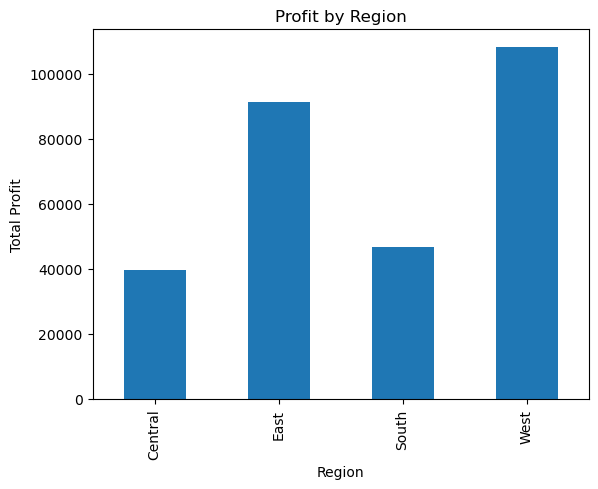

In [23]:
import matplotlib.pyplot as plt
data.groupby("Region")["Profit"].sum().plot(kind="bar")
plt.title("Profit by Region")
plt.ylabel("Total Profit")
plt.xlabel("Region")
plt.show()

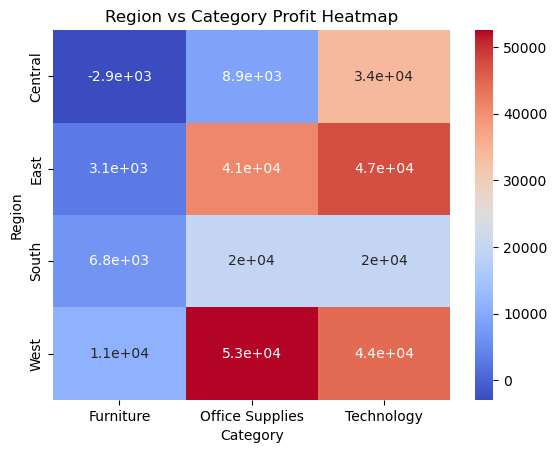

In [24]:
import seaborn as sns

pivot = data.pivot_table(values="Profit", index="Region", columns="Category", aggfunc="sum")

sns.heatmap(pivot, annot=True, cmap="coolwarm")

plt.title("Region vs Category Profit Heatmap")

plt.show()

In [25]:
data[data["Sub-Category"] == "Tables"].groupby("Discount")["Profit"].mean()

Discount
0.00    184.393051
0.20     -4.275465
0.30    -63.006067
0.40   -215.831957
0.45   -226.646464
0.50   -239.316314
Name: Profit, dtype: float64

In [26]:
data[data["Category"] == "Furniture"].groupby("Discount")["Profit"].mean()

Discount
0.00     69.654147
0.10     93.565946
0.15     27.288298
0.20     10.188535
0.30    -48.340534
0.32    -88.560656
0.40   -215.831957
0.45   -226.646464
0.50   -238.355537
0.60    -43.077212
0.70   -259.662627
Name: Profit, dtype: float64

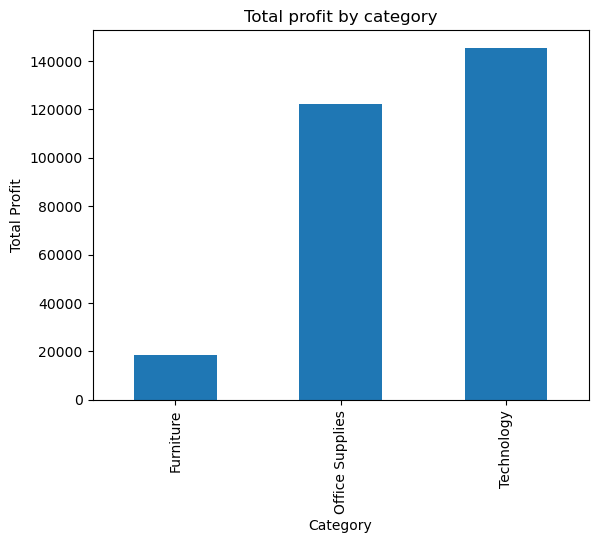

In [28]:
category_profit = data.groupby("Category")["Profit"].sum().sort_values()
category_profit.plot(kind="bar")
plt.title("Total profit by category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

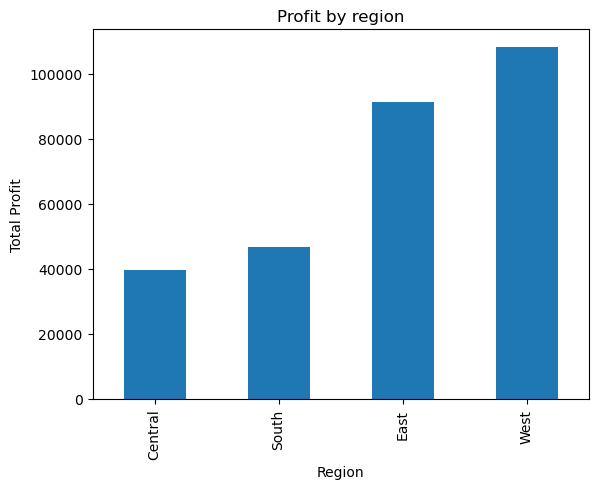

In [29]:
region_profit = data.groupby("Region")["Profit"].sum().sort_values()
region_profit.plot(kind="bar")
plt.title("Profit by region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.show()

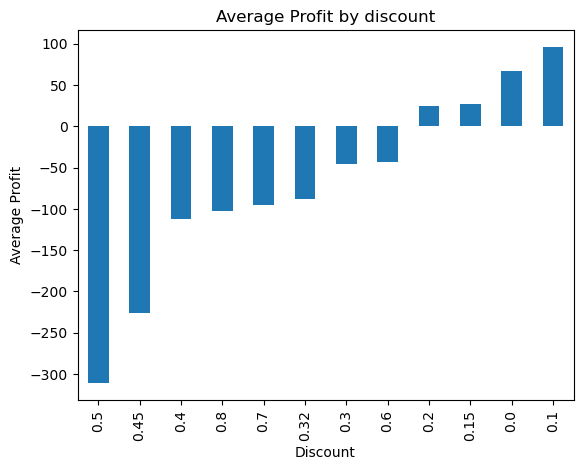

In [31]:
discount_profit = data.groupby("Discount")["Profit"].mean().sort_values()
discount_profit.plot(kind="bar")
plt.title("Average Profit by discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.show()